Computing the integral of a function using a fitting method

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [2]:
# Computes the integral of a function f using the trapezoid method with severals steps
def trap(f, a, b, max_N):

    N_values = np.arange(1, max_N + 1)
    integrals_list = []
    h_list = []
    
    for N in N_values:
        x = np.linspace(a, b, N + 1)
        y = f(x)
        h = (b - a) / N
        h_list.append(h)
        integrals_list.append(np.trapezoid(y, x))
    
    return (N_values, np.array(h_list), np.array(integrals_list))

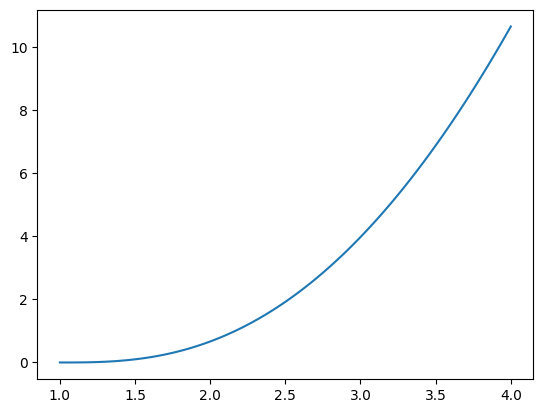

In [3]:
f = lambda x: x * np.log(x) ** 3 # f = x * log(x) ** 3
a, b, max_N = 1, 4, 100

# Fast plot of f
x = np.linspace(a, b, max_N)
plt.plot(x, f(x))
plt.show()

In [4]:
Ns, hs, Is = trap(f, a, b, max_N)

In [5]:
Ns, hs, Is

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
         66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
         79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
         92,  93,  94,  95,  96,  97,  98,  99, 100]),
 array([3.        , 1.5       , 1.        , 0.75      , 0.6       ,
        0.5       , 0.42857143, 0.375     , 0.33333333, 0.3       ,
        0.27272727, 0.25      , 0.23076923, 0.21428571, 0.2       ,
        0.1875    , 0.17647059, 0.16666667, 0.15789474, 0.15      ,
        0.14285714, 0.13636364, 0.13043478, 0.125     , 0.12      ,
        0.11538462, 0.11111111, 0.10714286, 0.10344828, 0.1       ,
        0.09677419, 0.0937

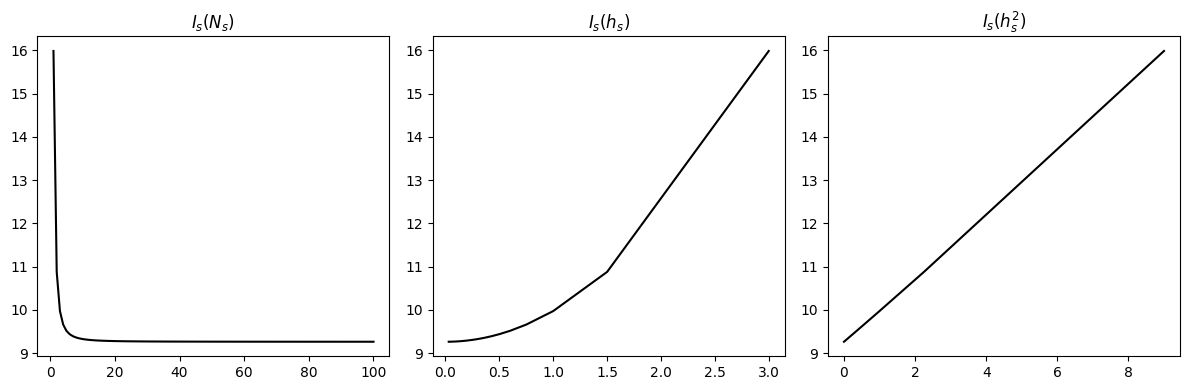

In [6]:
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

# Plot 1: Is(Ns)
axes[0].plot(Ns, Is, 'k-')
axes[0].set_title('$I_s (N_s)$')

# Plot 2: Is(hs)
axes[1].plot(hs, Is, 'k-')
axes[1].set_title('$I_s (h_s)$')

# Plot 3: Is(hs**2)
axes[2].plot(hs ** 2, Is, 'k-')
axes[2].set_title('$I_s (h_s^2)$')

plt.tight_layout()
plt.show()

In [7]:
# Fitting a straight line using the last 10 values of hs (near zero)
p = np.polyfit(hs[- 10:] ** 2, Is[- 10:], 1)
m, q = p

print(f"m = {m}")
print(f"q = {q}")

m = 0.7024859491072091
q = 9.262365384497109


In [8]:
# Real_value using quad()
real_value, _ = quad(f, a, b)
real_value

9.262365392656504

In [9]:
print(f"residual: {abs(real_value - q)}")

residual: 8.159394937479192e-09


In [10]:
# q is better than Is with 100 subdivisions
print(f"residual: {abs(real_value - Is[-1])}")

residual: 0.0006322292365101845
